# 13 - Structure diff end-to-end (library) - semantic + structural indicators

**Author** - kj &nbsp;|&nbsp; **Approach** - the shipped `docdistance` structure API: `opw_gap`, `order_alignment`, `structure_displacement`, `_build_diff` (what `DocDistance.distance_with_diff` wraps)

Notebook 12 proved the two-axis idea with the OPW math written inline. This notebook does the same story **end to end through the shipped library** - no re-implemented transport, every number comes from `docdistance`. Two documents in, and out come two indicators plus a per-statement diff: a semantic indicator (SMD closeness - how far in meaning), a structural indicator (order-gap closeness - how far in arrangement), and a diff that names *what changed in meaning* (`semantic_gap`) versus *what moved in order* (`displacement`).

- **Semantic** - `smd` then `closeness`, the order-invariant content axis
- **Structural** - `opw_gap` then `closeness`, the order-sensitive arrangement axis (E11-H55, the shipped SOTA number)
- **Interpretable** - `_build_diff` returns, per statement, `semantic_gap`, `displacement`, `moved`, `changed` - the exact indicators an agent reads to localize a change
- **Same fixture as nb12** - the curated IBM statements and pairs, but every value is a library call, not inline math

## GPU selection

mmBERT statement embedding runs on the freest GPU, pinned by UUID. The OT math is CPU numpy.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu  # RTX 5000 Ada
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"; os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(), "|",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.11.0+cu130 | cuda True | NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## Imports

The library under test - the shipped structure API, no re-implemented transport math.

In [2]:
get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import docdistance
from docdistance.distance import (
    smd, transport_plan, closeness, SMD_MAX,
    opw_plan, opw_cost, opw_gap,
    order_alignment, structure_displacement,
)
from docdistance.pipeline import _build_diff, DIFF_CHANGED_COST  # the builder DocDistance.distance_with_diff wraps
from docdistance.encoders import load_encoder

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("docdistance", docdistance.__version__)

docdistance 1.1.2


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
print(f"SEED={SEED}")

SEED=0


## Configuration

Every structure number is a shipped library call. The structural axis reads `opw_gap` through `closeness` - the same `1 - d/sqrt(2)` scale as semantic closeness, bounded [0, 1]. `DIFF_CHANGED_COST` is the library's cost cutoff that flags a statement as reworded.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
FIX = ROOT / "data/processed/structure-fixture"

REORDER_SWAPS = 14                          # seeded transpositions for the reordered-but-faithful pair

DOCS = json.loads((FIX / "statements.json").read_text())
ENC = load_encoder("torch", offline=True, device="cuda")
DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

def trunc(s, n=44):
    s = s.replace("\n", " ").strip()
    return s if len(s) <= n else s[: n - 1] + "."

t = Table(title="Notebook 13 configuration", title_style="bold medium_purple", show_header=False, box=None, padding=(0, 2))
t.add_column(style="grey70"); t.add_column()
t.add_row("Device", DEVICE)
t.add_row("Library", f"docdistance {docdistance.__version__}")
t.add_row("Structure metric", "opw_gap (E11-H55), read as closeness(gap)")
t.add_row("Readout scale", f"1 - d/sqrt(2),  sqrt(2) = {SMD_MAX:.4f}")
t.add_row("Diff builder", "_build_diff  (= DocDistance.distance_with_diff)")
t.add_row("changed cutoff", f"DIFF_CHANGED_COST = {DIFF_CHANGED_COST:.4f}")
t.add_row("Reorder", f"{REORDER_SWAPS} seeded swaps (byte-identical scramble)")
console.print(t)

                           Notebook 13 configuration                           
  Device              NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  
  Library             docdistance 1.1.2                                        
  Structure metric    opw_gap (E11-H55), read as closeness(gap)                
  Readout scale       1 - d/sqrt(2),  sqrt(2) = 1.4142                         
  Diff builder        _build_diff  (= DocDistance.distance_with_diff)          
  changed cutoff      DIFF_CHANGED_COST = 0.3889                               
  Reorder             14 seeded swaps (byte-identical scramble)

## Documents and pairs

The fixture supplies the gold IBM summary, its opus-mt back-translation (`gold~bt` - reworded, order preserved) and a different-content summary (`sonnet`). Two derived pairs isolate one axis each: a seeded reorder of gold (faithful content, rearranged order) and a single-statement content edit (one gold statement swapped for a prose statement from a different article, order kept). The reorder is the pure-structure case; the edit is the pure-semantic case.

In [5]:
ST_A = DOCS["gold"]["statements"]
ST_BT = DOCS["gold~bt"]["statements"]          # back-translation reword, same order
ST_S = DOCS["sonnet"]["statements"]
ST_W = DOCS["werg-a"]["statements"]            # a different article (AI in society) - genuine off-topic content
nA = len(ST_A)

EMB_A = ENC.encode(ST_A)
EMB_BT = ENC.encode(ST_BT)
EMB_S = ENC.encode(ST_S)
EMB_W = ENC.encode(ST_W)

# seeded reorder of gold (faithful content, rearranged order) - carry the texts too, for the diff targets
rng = np.random.default_rng(SEED); perm = np.arange(nA)
for _ in range(REORDER_SWAPS):
    a, b = int(rng.integers(0, nA)), int(rng.integers(0, nA)); perm[a], perm[b] = perm[b], perm[a]
EMB_A_RE = EMB_A[perm]
ST_A_RE = [ST_A[i] for i in perm]
reorder_disp = float(np.abs(perm - np.arange(nA)).sum()) / (nA * nA // 2)

# single-statement content edit: replace one gold statement with a prose statement from a different article
EDIT_K = 5
_wj = next(i for i, s in enumerate(ST_W) if len(s.strip()) > 60)   # first substantive (non-heading) werg statement
ST_A_ED = list(ST_A); ST_A_ED[EDIT_K] = ST_W[_wj]
EMB_A_ED = EMB_A.copy(); EMB_A_ED[EDIT_K] = EMB_W[_wj]

PAIRS = [
    {"name": "identity", "SA": ST_A, "EA": EMB_A, "SB": ST_A, "EB": EMB_A, "col": "#2ca02c"},
    {"name": "reordered-but-faithful", "SA": ST_A, "EA": EMB_A, "SB": ST_A_RE, "EB": EMB_A_RE, "col": "#d62728"},
    {"name": "paraphrased-but-faithful", "SA": ST_A, "EA": EMB_A, "SB": ST_BT, "EB": EMB_BT, "col": "#9467bd"},
    {"name": "different-content", "SA": ST_A, "EA": EMB_A, "SB": ST_S, "EB": EMB_S, "col": "#1f77b4"},
]
t = Table(title="Documents and pairs", title_style="bold medium_purple")
for c in ("pair", "doc A -> doc B", "n_A x n_B"):
    t.add_column(c, style="grey70" if c == "pair" else None)
t.add_row("identity", "gold -> gold", f"{nA}x{nA}")
t.add_row("reordered-but-faithful", f"gold -> gold ({REORDER_SWAPS} swaps, disp {reorder_disp:.2f})", f"{nA}x{nA}")
t.add_row("paraphrased-but-faithful", "gold -> gold~bt (back-translation reword)", f"{nA}x{len(ST_BT)}")
t.add_row("different-content", "gold -> sonnet", f"{nA}x{len(ST_S)}")
t.add_row("single-statement edit", f"gold -> gold with statement {EDIT_K} swapped (werg-a #{_wj})", f"{nA}x{nA}")
console.print(t)

                                    Documents and pairs                                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ pair                     ┃ doc A -> doc B                                    ┃ n_A x n_B ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ identity                 │ gold -> gold                                      │ 11x11     │
│ reordered-but-faithful   │ gold -> gold (14 swaps, disp 0.80)                │ 11x11     │
│ paraphrased-but-faithful │ gold -> gold~bt (back-translation reword)         │ 11x11     │
│ different-content        │ gold -> sonnet                                    │ 11x11     │
│ single-statement edit    │ gold -> gold with statement 5 swapped (werg-a #0) │ 11x11     │
└──────────────────────────┴───────────────────────────────────────────────────┴───────────┘

## Two-axis readout - semantic vs structural

Both indicators come off the same embeddings through library calls: `closeness(smd(...))` for content, `closeness(opw_gap(...))` for arrangement. The proof is the orthogonality - the reordered pair drops on structure, the paraphrased pair drops on semantic.

In [6]:
rows = []
for p in PAIRS:
    d_sem = smd(p["EA"], p["EB"])
    gap = max(opw_gap(p["EA"], p["EB"]), 0.0)
    rows.append({"pair": p["name"], "SMD": d_sem, "sem_close": closeness(d_sem),
                 "gap": gap, "struct_close": closeness(gap), "col": p["col"]})
readout = pd.DataFrame(rows)

t = Table(title="Two-axis readout - semantic (smd) vs structural (opw_gap), both via closeness()", title_style="bold medium_purple")
for c in ("pair", "SMD", "sem closeness", "order gap", "struct closeness", "reads as"):
    col_style = "grey70" if c == "pair" else (None if c == "reads as" else "dark_sea_green")
    t.add_column(c, justify="left" if c in ("pair", "reads as") else "right", style=col_style)
verdict = {"identity": "same / same", "reordered-but-faithful": "same meaning, changed arrangement",
           "paraphrased-but-faithful": "reworded meaning, same arrangement",
           "different-content": "different meaning, similar arrangement"}
for r in rows:
    style = "bold" if r["pair"] in ("reordered-but-faithful", "paraphrased-but-faithful") else None
    t.add_row(r["pair"], f'{r["SMD"]:.3f}', f'{r["sem_close"]:.3f}', f'{r["gap"]:.4f}',
              f'{r["struct_close"]:.3f}', verdict[r["pair"]], style=style)
console.print(t)

                  Two-axis readout - semantic (smd) vs structural (opw_gap), both via closeness()                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ pair                     ┃   SMD ┃ sem closeness ┃ order gap ┃ struct closeness ┃ reads as                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ identity                 │ 0.000 │         1.000 │    0.0002 │            1.000 │ same / same                   │
│ reordered-but-faithful   │ 0.000 │         1.000 │    0.4556 │            0.678 │ same meaning, changed         │
│                          │       │               │           │                  │ arrangement                   │
│ paraphrased-but-faithful │ 0.142 │         0.900 │    0.0005 │            1.000 │ reworded meaning, same        │
│                          │       │               │           │                  │ arrangement                   │
│ different-content        │ 0.253 │         0.821 │    0.1015 │            0.928 │ different meaning, similar    │
│                          │       │               │           │                  │ arrangement                   │
└──────────────────────────┴───────┴───────────────┴───────────┴──────────────────┴───────────────────────────────┘

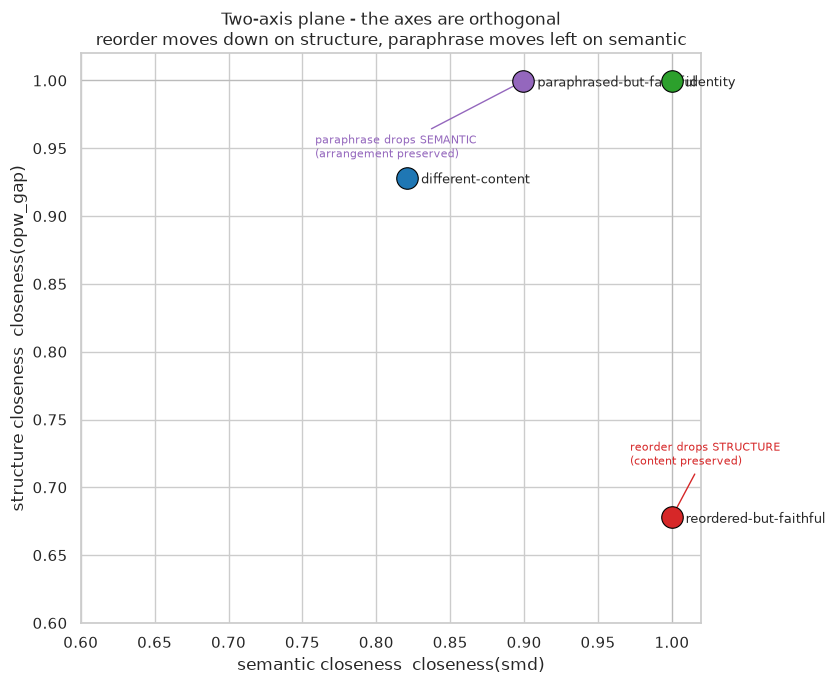

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.axhline(1.0, color="#bbbbbb", lw=0.8); ax.axvline(1.0, color="#bbbbbb", lw=0.8)
for r in rows:
    ax.scatter(r["sem_close"], r["struct_close"], s=240, color=r["col"], edgecolor="black", linewidth=0.8, zorder=5)
    ax.annotate(r["pair"], (r["sem_close"], r["struct_close"]), textcoords="offset points",
                xytext=(10, -4), fontsize=9)
ax.annotate("reorder drops STRUCTURE\n(content preserved)", (rows[1]["sem_close"], rows[1]["struct_close"]),
            textcoords="offset points", xytext=(-30, 38), fontsize=8, color="#d62728",
            arrowprops=dict(arrowstyle="->", color="#d62728"))
ax.annotate("paraphrase drops SEMANTIC\n(arrangement preserved)", (rows[2]["sem_close"], rows[2]["struct_close"]),
            textcoords="offset points", xytext=(-150, -55), fontsize=8, color="#9467bd",
            arrowprops=dict(arrowstyle="->", color="#9467bd"))
ax.set(xlim=(0.6, 1.02), ylim=(0.6, 1.02), xlabel="semantic closeness  closeness(smd)",
       ylabel="structure closeness  closeness(opw_gap)",
       title="Two-axis plane - the axes are orthogonal\nreorder moves down on structure, paraphrase moves left on semantic")
plt.tight_layout(); plt.show()

## The interpretable diff - what `distance_with_diff` returns

`_build_diff` is the builder behind `DocDistance.distance_with_diff`: top-level `smd`, `order_gap` and `structure_closeness`, then one entry per A statement carrying `semantic_gap` (meaning), `displacement` (order) and the `moved` / `changed` flags. Run it on the two single-axis pairs - the reorder lights up `displacement` / `moved` with every `semantic_gap` ~ 0, the single-statement edit lights up `semantic_gap` / `changed` on exactly one statement with every `displacement` 0. That is the orthogonality at the per-statement level, and exactly the JSON an agent reads to localize a change.

In [8]:
diff_re = _build_diff(ST_A, EMB_A, ST_A_RE, EMB_A_RE)      # reordered-but-faithful (pure structure)
diff_ed = _build_diff(ST_A, EMB_A, ST_A_ED, EMB_A_ED)      # single-statement content edit (pure semantic)

for name, dd in (("reorder", diff_re), ("edit", diff_ed)):
    n_moved = sum(s["moved"] for s in dd["statements"])
    n_changed = sum(s["changed"] for s in dd["statements"])
    print(f"{name:8}  smd={dd['smd']:.4f}  order_gap={dd['order_gap']:.4f}  "
          f"structure_closeness={dd['structure_closeness']:.4f}  |  moved={n_moved}  changed={n_changed}")

t = Table(title="Reorder diff - displacement names what MOVED (every semantic_gap ~ 0)", title_style="bold medium_purple")
for c in ("A idx", "statement", "-> B idx", "displacement", "moved", "sem_gap"):
    t.add_column(c, justify="left" if c == "statement" else "right",
                 style="grey70" if c in ("A idx", "-> B idx") else None)
for s in diff_re["statements"]:
    style = "dark_goldenrod" if s["moved"] else None
    t.add_row(str(s["index"]), trunc(s["text"]), str(s["target_index"]),
              f'{s["displacement"]:+d}', "yes" if s["moved"] else "-", f'{s["semantic_gap"]:.3f}', style=style)
console.print(t)

t = Table(title="Edit diff - semantic_gap names what CHANGED (every displacement 0)", title_style="bold medium_purple")
for c in ("A idx", "statement", "-> B idx", "sem_gap", "changed", "disp"):
    t.add_column(c, justify="left" if c == "statement" else "right",
                 style="grey70" if c in ("A idx", "-> B idx") else None)
for s in diff_ed["statements"]:
    style = "indian_red" if s["changed"] else None
    t.add_row(str(s["index"]), trunc(s["text"]), str(s["target_index"]),
              f'{s["semantic_gap"]:.3f}', "yes" if s["changed"] else "-", f'{s["displacement"]:+d}', style=style)
console.print(t)
print(f"\nreorder -> {sum(s['moved'] for s in diff_re['statements'])} moved / 0 changed  |  "
      f"edit -> 0 moved / {sum(s['changed'] for s in diff_ed['statements'])} changed  "
      f"(statement {EDIT_K} is the one edited)")

reorder   smd=0.0002  order_gap=0.4556  structure_closeness=0.6779  |  moved=11  changed=0
edit      smd=0.0403  order_gap=0.0003  structure_closeness=0.9998  |  moved=0  changed=1


               Reorder diff - displacement names what MOVED (every semantic_gap ~ 0)                
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓
┃ A idx ┃ statement                                    ┃ -> B idx ┃ displacement ┃ moved ┃ sem_gap ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩
│     0 │ # Executive Summary - Enterprise AI Adoptio. │        8 │           +8 │   yes │   0.001 │
│     1 │ Enterprise AI adoption has stalled at 42% a. │        0 │           -1 │   yes │   0.000 │
│     2 │ The primary bottleneck is a skills shortage. │        5 │           +3 │   yes │   0.001 │
│     3 │ Data complexity blocks 25% of organizations. │        7 │           +4 │   yes │   0.000 │
│     4 │ Geographic disparities are stark—India (59%. │        9 │           +5 │   yes │   0.000 │
│     5 │ Financial services leads by industry, with . │        2 │           -3 │   yes │   0.000 │
│     6 │ Generative AI introduces additional frictio. │       10 │           +4 │   yes │   0.000 │
│     7 │ Despite 85% of IT professionals agreeing th. │        4 │           -3 │   yes │   0.000 │
│     8 │ Cost reduction and process automation (42%). │        1 │           -7 │   yes │   0.001 │
│     9 │ Only 34% of organizations currently reskill. │        3 │           -6 │   yes │   0.000 │
│    10 │ Organizations should prioritize closing the. │        6 │           -4 │   yes │   0.000 │
└───────┴──────────────────────────────────────────────┴──────────┴──────────────┴───────┴─────────┘

              Edit diff - semantic_gap names what CHANGED (every displacement 0)              
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━┓
┃ A idx ┃ statement                                    ┃ -> B idx ┃ sem_gap ┃ changed ┃ disp ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━┩
│     0 │ # Executive Summary - Enterprise AI Adoptio. │        0 │   0.001 │       - │   +0 │
│     1 │ Enterprise AI adoption has stalled at 42% a. │        1 │   0.000 │       - │   +0 │
│     2 │ The primary bottleneck is a skills shortage. │        2 │   0.001 │       - │   +0 │
│     3 │ Data complexity blocks 25% of organizations. │        3 │   0.000 │       - │   +0 │
│     4 │ Geographic disparities are stark—India (59%. │        4 │   0.000 │       - │   +0 │
│     5 │ Financial services leads by industry, with . │        5 │   0.441 │     yes │   +0 │
│     6 │ Generative AI introduces additional frictio. │        6 │   0.000 │       - │   +0 │
│     7 │ Despite 85% of IT professionals agreeing th. │        7 │   0.000 │       - │   +0 │
│     8 │ Cost reduction and process automation (42%). │        8 │   0.001 │       - │   +0 │
│     9 │ Only 34% of organizations currently reskill. │        9 │   0.000 │       - │   +0 │
│    10 │ Organizations should prioritize closing the. │       10 │   0.000 │       - │   +0 │
└───────┴──────────────────────────────────────────────┴──────────┴─────────┴─────────┴──────┘


reorder -> 11 moved / 0 changed  |  edit -> 0 moved / 1 changed  (statement 5 is the one edited)


## Transport plans - content plan vs order-preserving plan

The structure signal is the gap between two library couplings of the same statements: `transport_plan` (content-optimal, exact EMD) and `opw_plan` (order-preserving Sinkhorn, polytope-rounded to a valid coupling). On a reorder the content plan goes off-diagonal to follow the moved statements; the OPW plan pays extra to stay in order, and `opw_cost - smd` is that extra cost, the gap.

opw_cost 0.4557 - smd 0.0002 = gap 0.4556  (opw_gap = 0.4556)


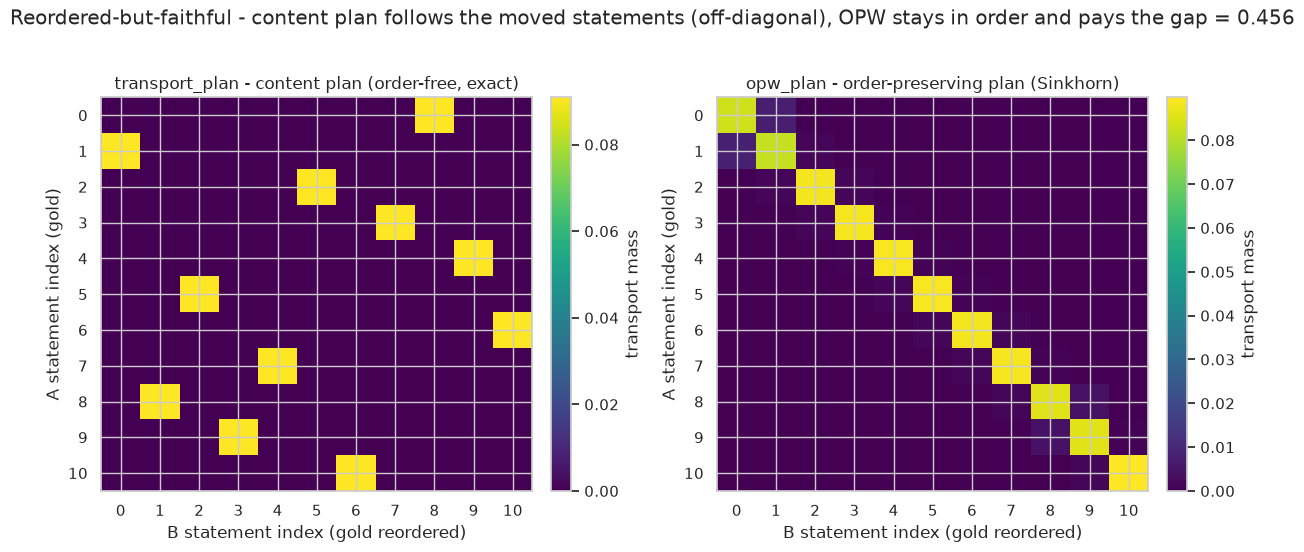

In [9]:
head = PAIRS[1]   # reordered-but-faithful
T_smd = transport_plan(head["EA"], head["EB"])     # content-optimal (exact EMD)
T_opw = opw_plan(head["EA"], head["EB"])           # order-preserving (Sinkhorn, polytope-rounded)
cost_opw = opw_cost(head["EA"], head["EB"]); d_smd = smd(head["EA"], head["EB"])
gap_head = max(opw_gap(head["EA"], head["EB"]), 0.0)
print(f"opw_cost {cost_opw:.4f} - smd {d_smd:.4f} = gap {cost_opw - d_smd:.4f}  (opw_gap = {gap_head:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax, T, title in ((axes[0], T_smd, "transport_plan - content plan (order-free, exact)"),
                     (axes[1], T_opw, "opw_plan - order-preserving plan (Sinkhorn)")):
    im = ax.imshow(T, cmap="viridis", aspect="auto")
    ax.set(xlabel="B statement index (gold reordered)", ylabel="A statement index (gold)", title=title)
    ax.set_xticks(range(len(head["EB"]))); ax.set_yticks(range(len(head["EA"])))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="transport mass")
fig.suptitle(f"Reordered-but-faithful - content plan follows the moved statements (off-diagonal), "
             f"OPW stays in order and pays the gap = {gap_head:.3f}", y=1.02)
plt.tight_layout(); plt.show()

## Movers - per-statement displacement via `structure_displacement`

`structure_displacement` is the library's per-statement rank shift off the crisp exact-EMD alignment - `0` in place, nonzero moved. It is the same integer vector the diff's `displacement` field carries; here as a bar chart naming which statements the gap charges for.

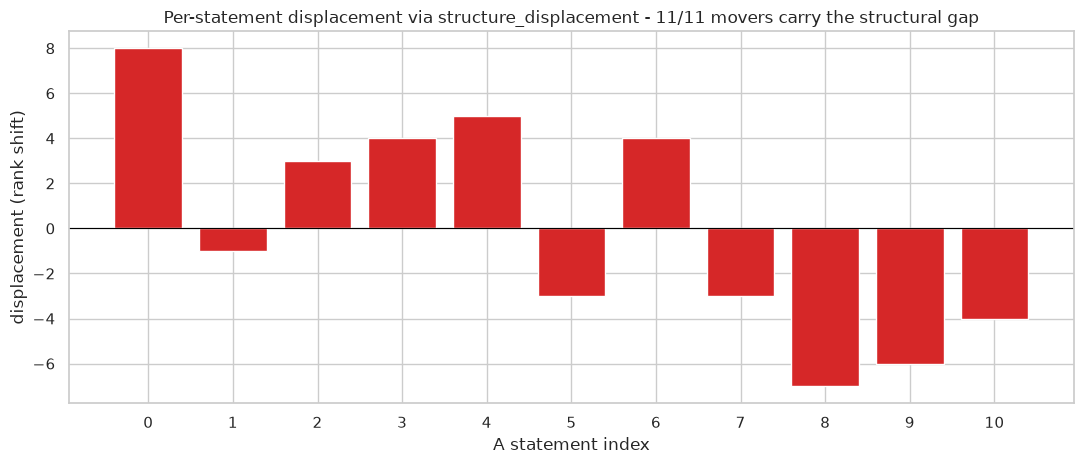

largest movers (order_alignment -> target):
  statement 0 -> B[8] (displacement +8): # Executive Summary - Enterprise AI Adoptio.
  statement 8 -> B[1] (displacement -7): Cost reduction and process automation (42%).
  statement 9 -> B[3] (displacement -6): Only 34% of organizations currently reskill.


In [10]:
disp = structure_displacement(EMB_A, EMB_A_RE)
assert disp.tolist() == [s["displacement"] for s in diff_re["statements"]]  # same numbers as the diff field
n_movers = int((disp != 0).sum())

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(np.arange(nA), disp, color=["#d62728" if d else "#9aa7b4" for d in disp])
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="A statement index", ylabel="displacement (rank shift)",
       title=f"Per-statement displacement via structure_displacement - {n_movers}/{nA} movers carry the structural gap")
ax.set_xticks(np.arange(nA))
plt.tight_layout(); plt.show()

align = order_alignment(EMB_A, EMB_A_RE)
top = np.argsort(-np.abs(disp))[:3]
print("largest movers (order_alignment -> target):")
for i in top:
    print(f"  statement {i} -> B[{int(align[i])}] (displacement {disp[i]:+d}): {trunc(ST_A[i])}")

## Conclusion

The shipped library carries the whole two-axis story end to end, with the per-statement diff as the interpretable readout. Every number below is read off the executed cells above.

- **Two orthogonal indicators** - the reorder holds semantic closeness at 1.00 while structure drops 1.00 -> 0.68 (`order_gap` 0.456); the paraphrase drops semantic 1.00 -> 0.90 (`smd` 0.142) while structure holds at 1.00 (`order_gap` 0.0005) - content and arrangement move independently
- **The diff localizes both axes** - `_build_diff` (what `DocDistance.distance_with_diff` returns) names it per statement: the reorder reads 11/11 `moved`, 0 `changed`, every `semantic_gap` ~ 0 (structural localization); the single-statement edit reads 0 `moved`, 1 `changed` on statement 5, every `displacement` 0 (semantic localization)
- **No inline transport math** - `opw_plan`, `opw_cost`, `opw_gap`, `order_alignment`, `structure_displacement`, `transport_plan` are all shipped; `opw_cost - smd = gap` reconciled (0.456) and `structure_displacement` reproduced the diff `displacement` field exactly (asserted in the movers cell)
- **Machine-readable** - the CLI `docdistance distance A B --diff-json FILE` emits the same dict, so an agent gets the "what changed in meaning vs what moved in order" indicators directly